<a href="https://colab.research.google.com/github/mewtwox44/ML-SKILL/blob/main/week_6_Skill.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload your Iris CSV dataset:


Saving Iris.csv to Iris.csv

Dataset loaded successfully!
File: Iris.csv

========== FIRST 5 ROWS ==========
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

========== DATASET SHAPE ==========
(150, 6)

========== COLUMN NAMES ==========
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-

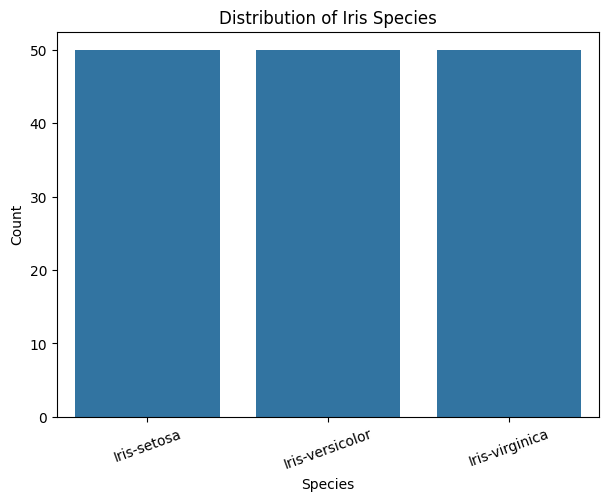


========== FEATURES USED ==========
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Number of features: 4

========== MISSING VALUES AFTER CLEANING ==========
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


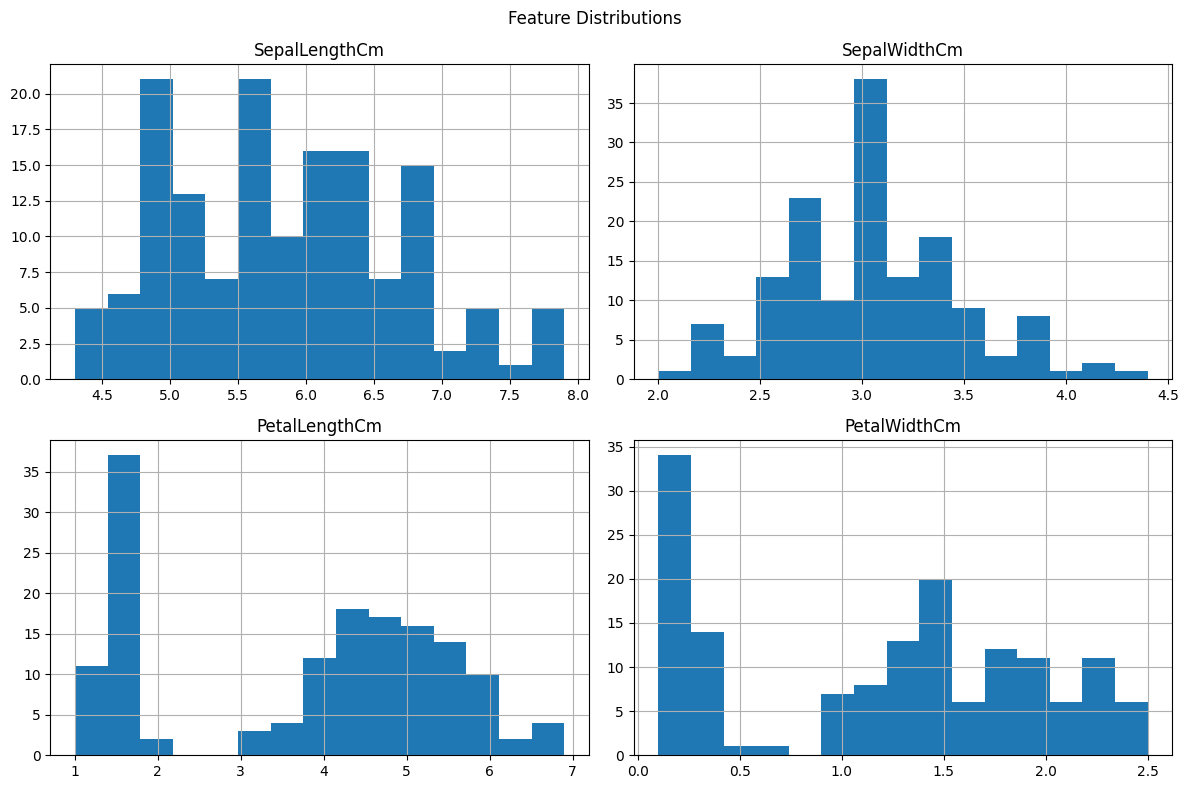

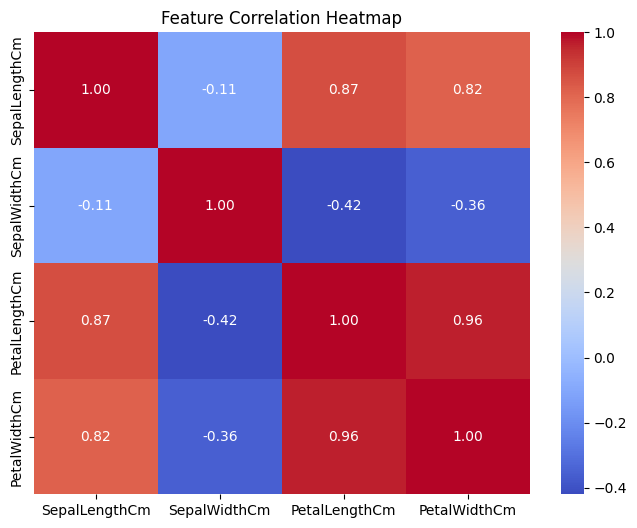

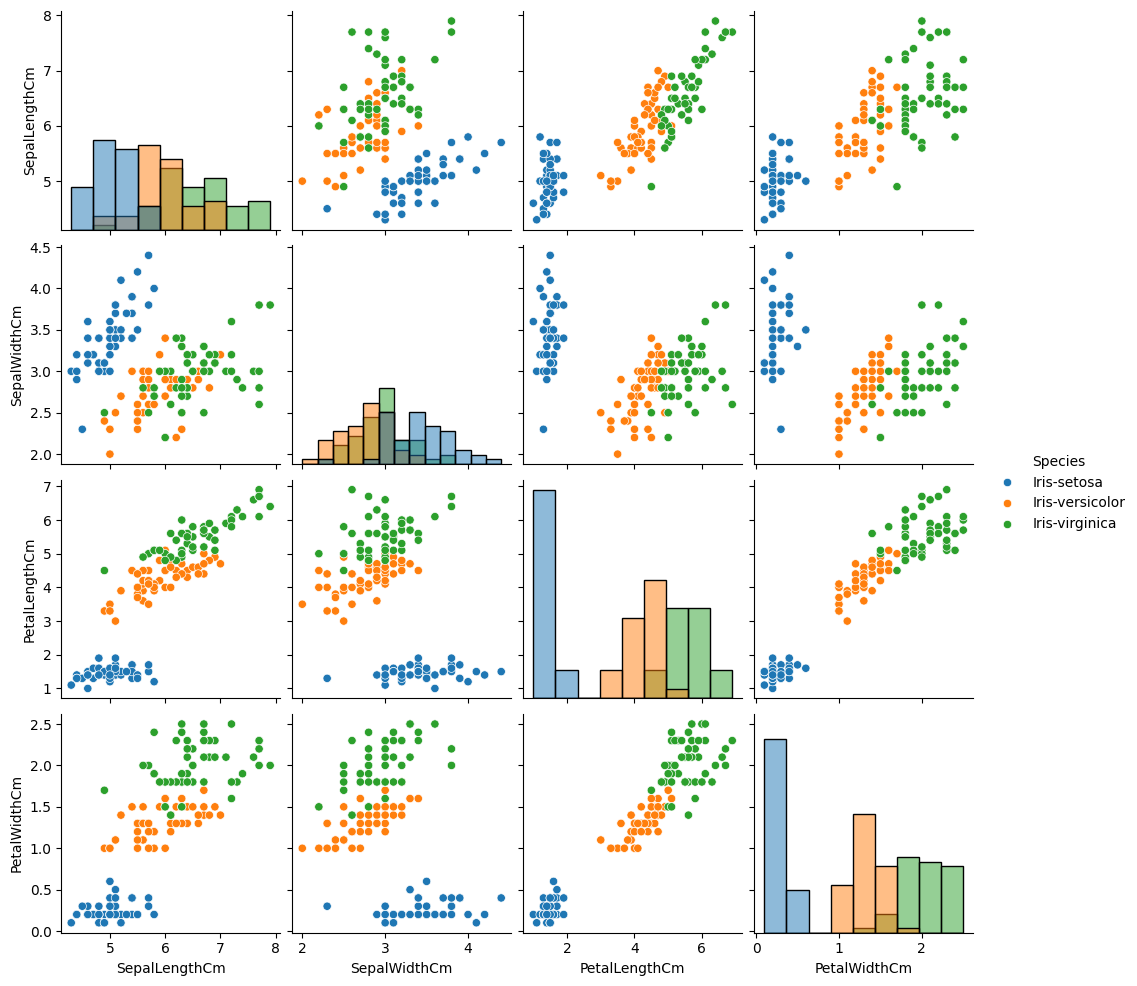


========== TRAIN-TEST SPLIT ==========
Training samples: 120
Testing samples: 30

Feature scaling completed.

========== MODEL TRAINING ==========
Multinomial Logistic Regression model trained successfully.

========== MODEL PERFORMANCE ==========
Accuracy : 0.9333
Precision: 0.9333
Recall   : 0.9333
F1 Score : 0.9333

========== CLASSIFICATION REPORT ==========
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


========== CONFUSION MATRIX ==========
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


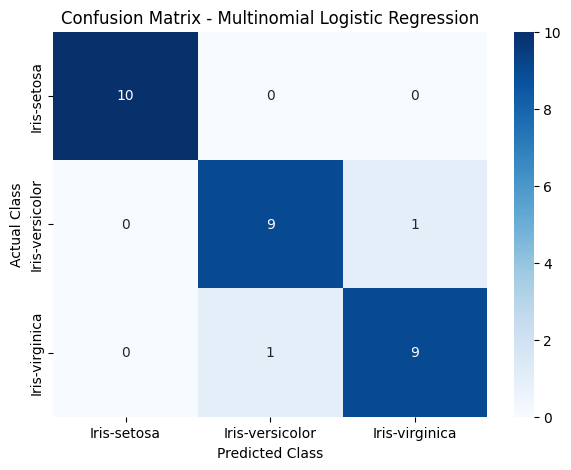


Multiclass ROC-AUC: 0.9967

========== MODEL COEFFICIENTS ==========
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Iris-setosa          -1.091782      1.020342      -1.797617     -1.695241
Iris-versicolor       0.538893     -0.359539      -0.207911     -0.800662
Iris-virginica        0.552890     -0.660802       2.005529      2.495903


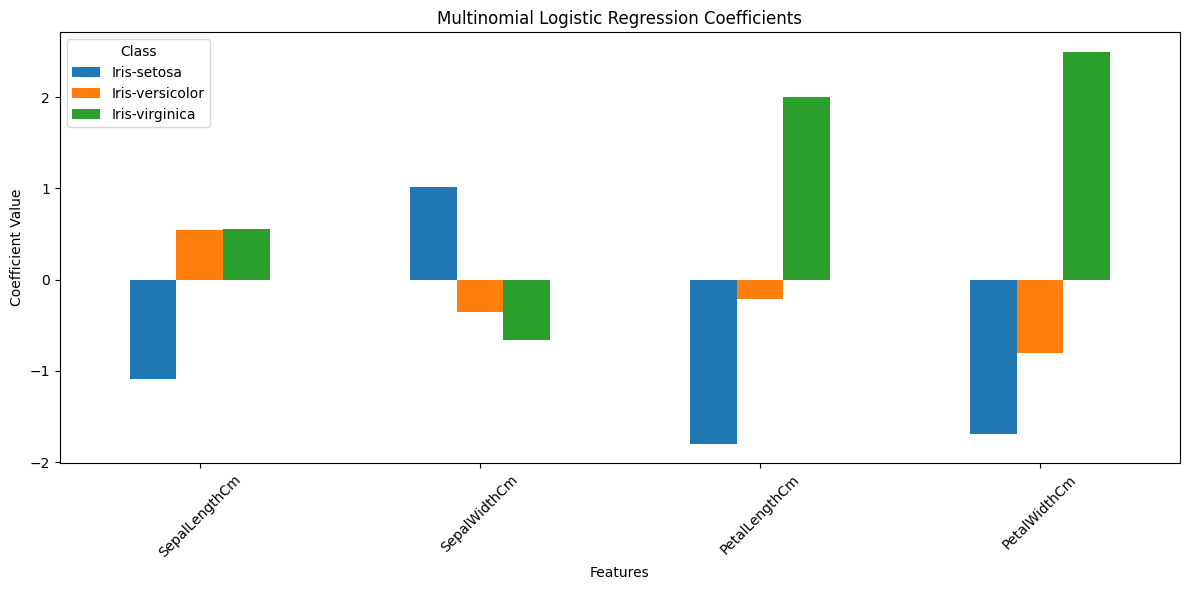


========== ACTUAL VS PREDICTED ==========
             Actual        Predicted
0       Iris-setosa      Iris-setosa
1    Iris-virginica   Iris-virginica
2   Iris-versicolor  Iris-versicolor
3   Iris-versicolor  Iris-versicolor
4       Iris-setosa      Iris-setosa
5   Iris-versicolor  Iris-versicolor
6       Iris-setosa      Iris-setosa
7       Iris-setosa      Iris-setosa
8    Iris-virginica   Iris-virginica
9   Iris-versicolor  Iris-versicolor
10   Iris-virginica   Iris-virginica
11   Iris-virginica   Iris-virginica
12   Iris-virginica   Iris-virginica
13  Iris-versicolor  Iris-versicolor
14      Iris-setosa      Iris-setosa
15      Iris-setosa      Iris-setosa
16      Iris-setosa      Iris-setosa
17  Iris-versicolor  Iris-versicolor
18  Iris-versicolor  Iris-versicolor
19   Iris-virginica   Iris-virginica

========== PREDICTED CLASS PROBABILITIES ==========
    Iris-setosa  Iris-versicolor  Iris-virginica           Actual  \
0      0.979355         0.020644    3.582230e-07      Iris

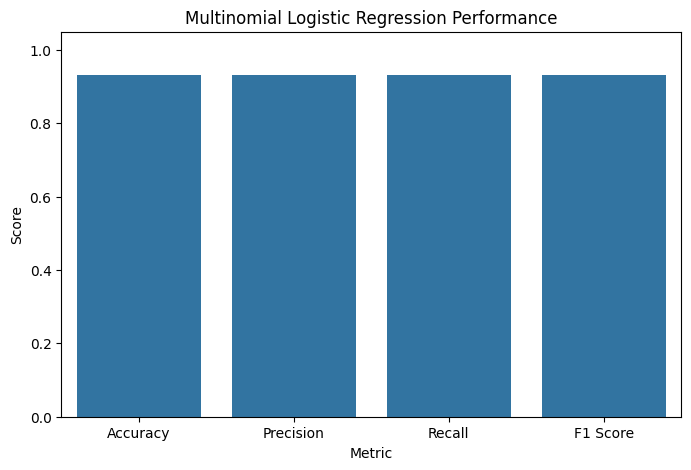


FINAL CONCLUSION
Multinomial Logistic Regression was successfully implemented to classify Iris flowers into multiple species.
The model achieved an accuracy of 0.9333 on the test dataset.
Feature scaling was applied before training because Logistic Regression performs better when numerical features are on comparable scales.
The confusion matrix and classification report were used to evaluate the classification performance of each Iris species.
The model coefficients show the influence of each feature on the different classes.

Project 6 completed successfully!


In [1]:
# ============================================================
# PROJECT 6: MULTINOMIAL LOGISTIC REGRESSION
# Dataset: Iris Flower Dataset
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ============================================================
# 2. UPLOAD DATASET
# ============================================================

print("Upload your Iris CSV dataset:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("\nDataset loaded successfully!")
print("File:", filename)

# ============================================================
# 3. BASIC DATASET INFORMATION
# ============================================================

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print(df.duplicated().sum())

# ============================================================
# 4. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

# Remove unnecessary ID columns if present
columns_to_drop = []

for col in df.columns:
    if col.lower() in ["id", "unnamed: 0"]:
        columns_to_drop.append(col)

if len(columns_to_drop) > 0:
    df = df.drop(columns=columns_to_drop)

print("\n========== COLUMNS AFTER CLEANING ==========")
print(df.columns.tolist())

# ============================================================
# 5. FIND TARGET COLUMN
# ============================================================

possible_targets = ["species", "class", "target", "label"]

target_column = None

for col in df.columns:
    if col.lower() in possible_targets:
        target_column = col
        break

if target_column is None:
    print("\nTarget column was not automatically detected.")
    print("Available columns:", df.columns.tolist())
    raise ValueError("Please use a dataset containing a Species/Class/Target column.")

print("\nTarget column:", target_column)

# ============================================================
# 6. CHECK TARGET CLASSES
# ============================================================

print("\n========== TARGET CLASSES ==========")
print(df[target_column].value_counts())

print("\nNumber of classes:", df[target_column].nunique())

# ============================================================
# 7. EXPLORATORY DATA ANALYSIS
# ============================================================

# Class distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target_column
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()


# ============================================================
# 8. SELECT NUMERICAL FEATURES
# ============================================================

X = df.drop(columns=[target_column])

# Keep only numerical columns
X = X.select_dtypes(include=np.number)

y = df[target_column]

print("\n========== FEATURES USED ==========")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

# ============================================================
# 9. HANDLE MISSING VALUES
# ============================================================

for column in X.columns:
    X[column] = X[column].fillna(X[column].median())

print("\n========== MISSING VALUES AFTER CLEANING ==========")
print(X.isnull().sum())

# ============================================================
# 10. FEATURE DISTRIBUTION
# ============================================================

X.hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

# ============================================================
# 11. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

# ============================================================
# 12. PAIRPLOT
# ============================================================

plot_df = X.copy()
plot_df["Species"] = y.values

sns.pairplot(
    plot_df,
    hue="Species",
    diag_kind="hist"
)

plt.show()

# ============================================================
# 13. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== TRAIN-TEST SPLIT ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# ============================================================
# 14. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")

# ============================================================
# 15. CREATE MULTINOMIAL LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

# ============================================================
# 16. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)

print("\n========== MODEL TRAINING ==========")
print("Multinomial Logistic Regression model trained successfully.")

# ============================================================
# 17. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_test_scaled)

# Probability of each class
y_prob = model.predict_proba(X_test_scaled)

# ============================================================
# 18. MODEL PERFORMANCE
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\n========== MODEL PERFORMANCE ==========")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

# ============================================================
# 19. CLASSIFICATION REPORT
# ============================================================

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# 20. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n========== CONFUSION MATRIX ==========")
print(cm)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix - Multinomial Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

# ============================================================
# 21. MULTICLASS ROC-AUC
# ============================================================

try:

    roc_auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr"
    )

    print("\nMulticlass ROC-AUC:", round(roc_auc, 4))

except Exception as e:

    print("\nROC-AUC could not be calculated:", e)

# ============================================================
# 22. MODEL COEFFICIENTS
# ============================================================

coefficient_df = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=model.classes_
)

print("\n========== MODEL COEFFICIENTS ==========")

print(coefficient_df)

# ============================================================
# 23. COEFFICIENT VISUALIZATION
# ============================================================

coefficient_df.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Multinomial Logistic Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.legend(title="Class")

plt.tight_layout()
plt.show()

# ============================================================
# 24. ACTUAL VS PREDICTED VALUES
# ============================================================

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")

print(comparison_df.head(20))

# ============================================================
# 25. PREDICTED PROBABILITIES
# ============================================================

probability_df = pd.DataFrame(
    y_prob,
    columns=model.classes_
)

probability_df["Actual"] = y_test.values
probability_df["Predicted"] = y_pred

print("\n========== PREDICTED CLASS PROBABILITIES ==========")

print(probability_df.head(20))

# ============================================================
# 26. PERFORMANCE SUMMARY TABLE
# ============================================================

performance_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

print("\n========== PERFORMANCE SUMMARY ==========")

print(performance_df)

# ============================================================
# 27. PERFORMANCE GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=performance_df,
    x="Metric",
    y="Score"
)

plt.ylim(0, 1.05)
plt.title("Multinomial Logistic Regression Performance")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.show()

# ============================================================
# 28. FINAL CONCLUSION
# ============================================================

print("\n===================================================")
print("FINAL CONCLUSION")
print("===================================================")

print(
    "Multinomial Logistic Regression was successfully "
    "implemented to classify Iris flowers into multiple species."
)

print(
    f"The model achieved an accuracy of {accuracy:.4f} "
    f"on the test dataset."
)

print(
    "Feature scaling was applied before training because "
    "Logistic Regression performs better when numerical "
    "features are on comparable scales."
)

print(
    "The confusion matrix and classification report were "
    "used to evaluate the classification performance of "
    "each Iris species."
)

print(
    "The model coefficients show the influence of each "
    "feature on the different classes."
)

print("\nProject 6 completed successfully!")